In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('../data/clustered_data.csv')

In [3]:
df.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,District,Ward,Community Area,Latitude,Longitude,hour,day,month,year,weekend,cluster,size,time_cluster
0,13986460,2025-10-01 20:30:00,BATTERY,DOMESTIC BATTERY SIMPLE,STREET,False,True,15,37.0,25.0,41.880368,-87.755370,20,3,10,2025,False,5,49991,2
1,13838422,2025-05-17 06:50:00,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,17,39.0,13.0,41.983649,-87.716222,6,6,5,2025,True,4,65663,3
2,13929304,2025-08-09 16:32:00,NARCOTICS,POSSESS - CANNABIS MORE THAN 30 GRAMS,STREET,True,False,3,7.0,43.0,41.759814,-87.571246,16,6,8,2025,True,2,79721,2
3,14019859,2025-08-20 15:30:00,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,BANK,False,False,22,19.0,72.0,41.720967,-87.680207,15,3,8,2025,False,3,73943,0
4,13521832,2024-07-07 16:30:00,ASSAULT,"PROTECTED EMPLOYEE - HANDS, FISTS, FEET, NO / ...",GAS STATION,False,False,3,5.0,43.0,41.772999,-87.576479,16,0,7,2024,True,2,79721,2


In [4]:
df.duplicated().sum()

np.int64(0)

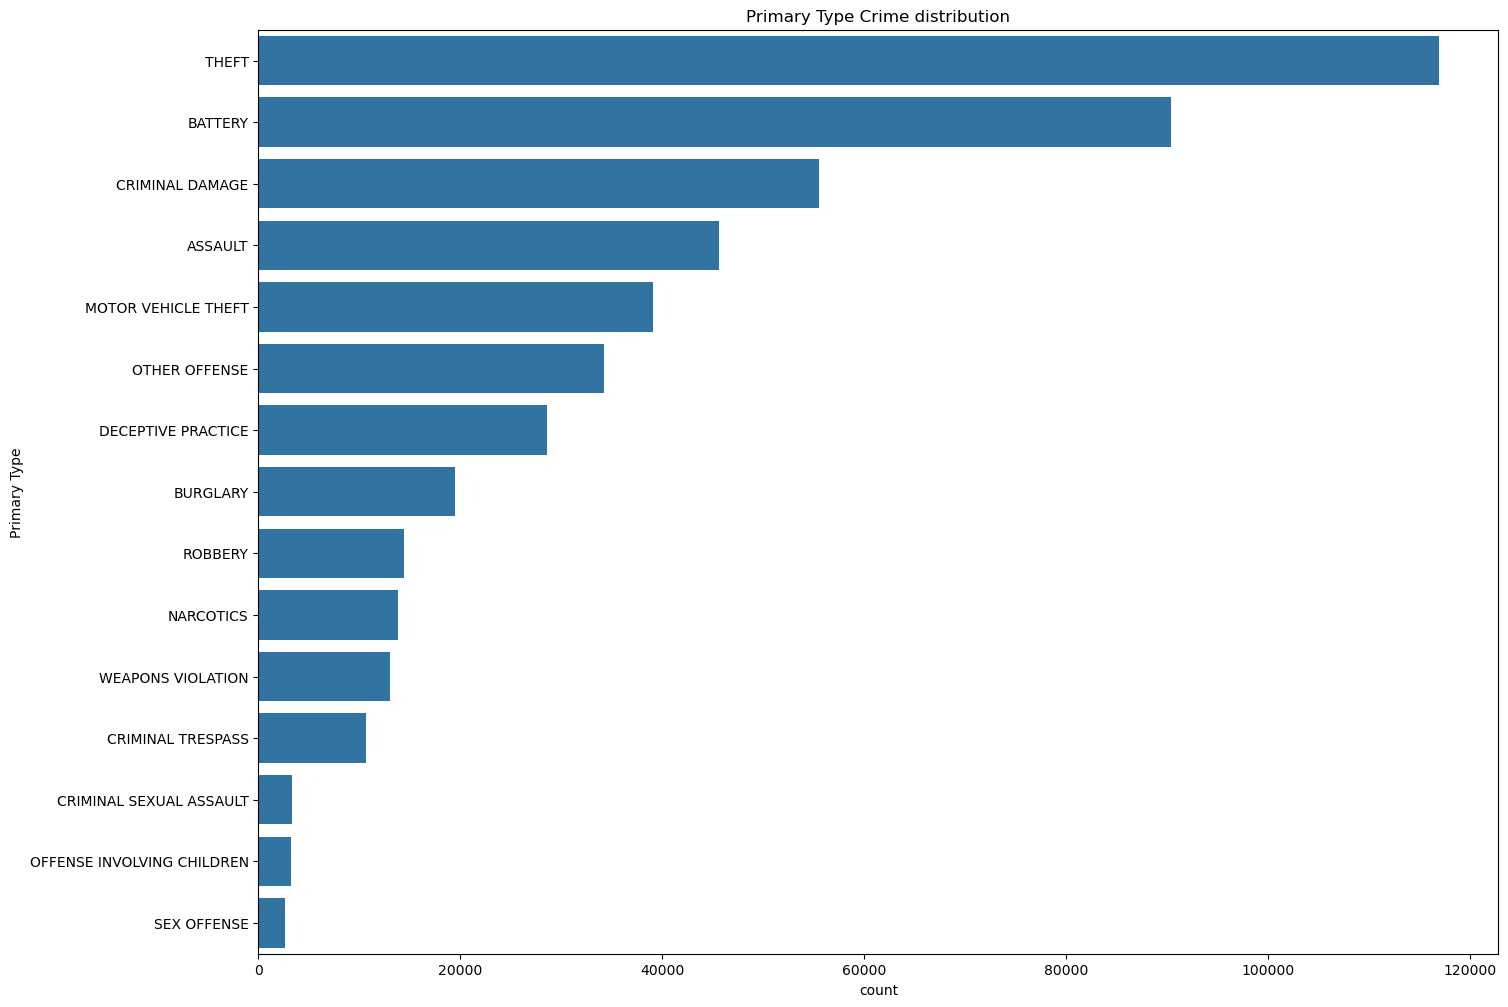

In [5]:
plt.figure(figsize=(16,12))
plt.title('Primary Type Crime distribution')
sns.countplot(y=df['Primary Type'],
order=df['Primary Type'].value_counts().index[:15])
plt.show()


<Axes: xlabel='hour', ylabel='Count'>

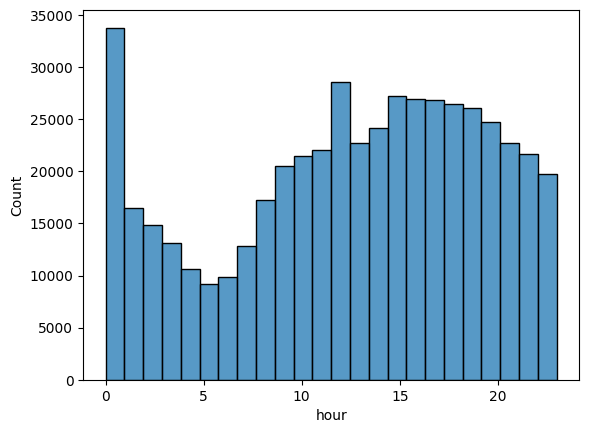

In [10]:
sns.histplot(df['hour'], bins=24)


In [ ]:
df['Arrest'].value_counts()


array([424844,  75156])

(np.float64(-1.099999984908503),
 np.float64(1.09999982229478),
 np.float64(-1.1046043828659913),
 np.float64(1.1966930140143448))

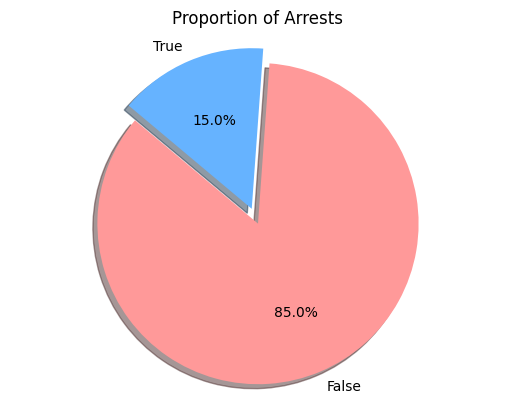

In [20]:
colors = ['#ff9999','#66b3ff'] # Soft red and blue
explode = (0, 0.1)  # "Explode" the 'True' slice to make it stand out

# Create the pie chart
plt.pie(df['Arrest'].value_counts().values, explode=explode, labels=df['Arrest'].value_counts().index, colors=colors, 
        autopct='%1.1f%%', shadow=True, startangle=140)

plt.title('Proportion of Arrests')
plt.axis('equal')

<Axes: xlabel='Domestic', ylabel='count'>

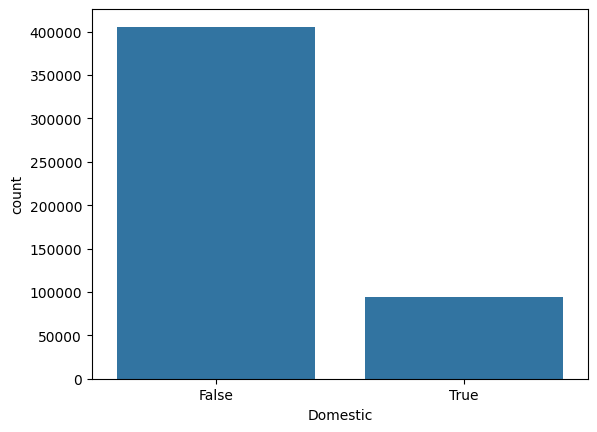

In [13]:
sns.countplot(x='Domestic', data=df)


In [6]:
df.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,District,Ward,Community Area,Latitude,Longitude,hour,day,month,year,weekend,cluster,size,time_cluster
0,13986460,2025-10-01 20:30:00,BATTERY,DOMESTIC BATTERY SIMPLE,STREET,False,True,15,37.0,25.0,41.880368,-87.755370,20,3,10,2025,False,5,49991,2
1,13838422,2025-05-17 06:50:00,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,17,39.0,13.0,41.983649,-87.716222,6,6,5,2025,True,4,65663,3
2,13929304,2025-08-09 16:32:00,NARCOTICS,POSSESS - CANNABIS MORE THAN 30 GRAMS,STREET,True,False,3,7.0,43.0,41.759814,-87.571246,16,6,8,2025,True,2,79721,2
3,14019859,2025-08-20 15:30:00,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,BANK,False,False,22,19.0,72.0,41.720967,-87.680207,15,3,8,2025,False,3,73943,0
4,13521832,2024-07-07 16:30:00,ASSAULT,"PROTECTED EMPLOYEE - HANDS, FISTS, FEET, NO / ...",GAS STATION,False,False,3,5.0,43.0,41.772999,-87.576479,16,0,7,2024,True,2,79721,2


In [8]:
df.dtypes

ID                        int64
Date                        str
Primary Type                str
Description                 str
Location Description        str
Arrest                     bool
Domestic                   bool
District                  int64
Ward                    float64
Community Area          float64
Latitude                float64
Longitude               float64
hour                      int64
day                       int64
month                     int64
year                      int64
weekend                    bool
cluster                   int64
size                      int64
time_cluster              int64
dtype: object

In [16]:
df[(df['time_cluster']==2)]['day'].value_counts()

day
5    25958
6    25281
1    23787
3    23784
4    23647
0    23410
2    23189
Name: count, dtype: int64

In [17]:
df['day'].value_counts()

day
5    74077
6    73472
1    71975
0    71307
3    70437
4    70130
2    68602
Name: count, dtype: int64

In [19]:
df['month'].value_counts()

month
3     55249
7     46472
6     44046
8     44031
10    43156
9     43057
5     42486
4     39180
11    37888
12    36827
1     35017
2     32591
Name: count, dtype: int64

In [25]:
season_map={
    1:'winter',
    2:'winter',
    3:'spring',
    4:'spring',
    5:'spring',
    6:'summer',
    7:'summer',
    8:'summer',
    9:'fall',
    10:'fall',
    11:'fall',
    12:'winter'
}

In [26]:
df['season']=df['month'].map(season_map)

In [27]:
df['season'].value_counts()

season
spring    136915
summer    134549
fall      124101
winter    104435
Name: count, dtype: int64

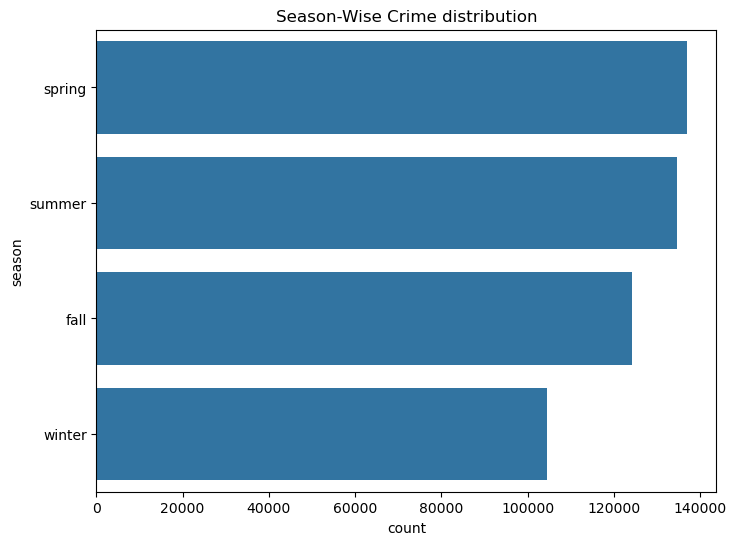

In [31]:
plt.figure(figsize=(8,6))
plt.title('Season-Wise Crime distribution')
sns.countplot(y=df['season'],
order=df['season'].value_counts().index)
plt.show()

In [ ]:
st.markdown(
    f"<h4 style='color:#FF0000;'font-size:20px;'>from 4pm till 12am Crime Rate is high 
    </h4>",
    unsafe_allow_html=True
)

In [33]:
df1=pd.read_csv('../data/visualize.csv')

In [34]:
df1.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,District,Ward,Community Area,...,Longitude,hour,day,month,year,weekend,cluster,size,time_cluster,season
0,13986460,2025-10-01 20:30:00,BATTERY,DOMESTIC BATTERY SIMPLE,STREET,False,True,15,37.0,25.0,...,-87.755370,20,3,10,2025,False,5,49991,2,fall
1,13838422,2025-05-17 06:50:00,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,17,39.0,13.0,...,-87.716222,6,6,5,2025,True,4,65663,3,spring
2,13929304,2025-08-09 16:32:00,NARCOTICS,POSSESS - CANNABIS MORE THAN 30 GRAMS,STREET,True,False,3,7.0,43.0,...,-87.571246,16,6,8,2025,True,2,79721,2,summer
3,14019859,2025-08-20 15:30:00,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,BANK,False,False,22,19.0,72.0,...,-87.680207,15,3,8,2025,False,3,73943,0,summer
4,13521832,2024-07-07 16:30:00,ASSAULT,"PROTECTED EMPLOYEE - HANDS, FISTS, FEET, NO / ...",GAS STATION,False,False,3,5.0,43.0,...,-87.576479,16,0,7,2024,True,2,79721,2,summer
